# Modern Earth Reflected Spectrum: Deeper Surface Pressure Sweep (Cloud Height Fixed)

This notebook reuses the Modern Earth reflected-spectrum setup and sweeps to deeper surface pressures while keeping the Earth cloud deck fixed at the same pressure height (0.6-0.7 bar).

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u

current_directory = Path.cwd()
references_directory_path = "Installation&Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation&Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)

import picaso.justdoit as jdi

/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds


/gscratch/stf/elizap/envs/subneptune/lib/python3.12/site-packages/picaso/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import declare_namespace


In [2]:
current_directory = Path.cwd()
opacity_file_path = "Installation&Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000.db"  
opacity_path=os.path.join(current_directory, opacity_file_path)
print(opacity_path)

/mmfs1/gscratch/stf/elizap/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000.db


In [3]:
# Modern Earth composition (constant with altitude)
df_mol_modern_earth = {
    "N2": 0.79,
    "O2": 0.21,
    "O3": 7e-7,
    "H2O": 3e-3,
    "CO2": 300e-6,
    "CH4": 1.7e-6
}

In [8]:
def earth_spectrum_surface_sweep(
    opacity_path,
    df_mol_earth,
    phase=0.0,
    p_surface_bar=1.0,
    nlevel=90,
    cloud_ptop_bar=0.6,
    cloud_pbot_bar=0.7
):
    """
    Compute Modern Earth reflected spectrum with a variable surface pressure.
    Cloud deck stays fixed in pressure space (same atmospheric height proxy).
    """
    if p_surface_bar <= 0:
        raise ValueError("p_surface_bar must be > 0")

    if cloud_pbot_bar > p_surface_bar:
        raise ValueError(
            f"cloud_pbot_bar ({cloud_pbot_bar}) is deeper than p_surface_bar ({p_surface_bar})"
        )

    earth = jdi.inputs()
    earth.phase_angle(phase, num_tangle=8, num_gangle=8)
    earth.gravity(radius=1, radius_unit=jdi.u.Unit('R_earth'), mass=1, mass_unit=jdi.u.Unit('M_earth'))
    earth.approx(raman="none")

    opacity = jdi.opannection(filename_db=opacity_path, wave_range=[0.3, 2.5])
    earth.star(
        opannection=opacity,
        temp=5778,
        logg=4.4,
        semi_major=1,
        metal=0.0,
        semi_major_unit=u.Unit('au')
    )

    # Extend the profile deeper by increasing the bottom pressure limit
    p_top_bar = -6 #replaced 1e-6 with just -6
    P = np.logspace(p_top_bar, np.log10(p_surface_bar), nlevel)
    df_atmo = earth.TP_line_earth(P, nlevel=nlevel)

    df_pt_earth = pd.DataFrame({
        'pressure': df_atmo['pressure'].values,
        'temperature': df_atmo['temperature'].values
    })

    df_mol_earth_grid = pd.DataFrame({
        key: (P * 0 + val) for key, val in df_mol_earth.items()
    })

    df_atmo_earth = df_pt_earth.join(df_mol_earth_grid, how='inner')
    earth.atmosphere(df=df_atmo_earth)
    earth.surface_reflect(0.1, opacity.wno)

    # Cloud-free spectrum
    df_cldfree = earth.spectrum(opacity, calculation='reflected', full_output=True)

    # Earth cloud deck fixed at same pressure height
    logdp = np.log10(cloud_pbot_bar) - np.log10(cloud_ptop_bar)
    log_pbot = np.log10(cloud_pbot_bar)
    earth.clouds(w0=[0.99], g0=[0.85], p=[log_pbot], dp=[logdp], opd=[10])

    df_cld = earth.spectrum(opacity, full_output=True)

    wno = df_cldfree['wavenumber']
    fpfs = df_cldfree['fpfs_reflected']
    albedo = df_cldfree['albedo']

    fpfs_c = df_cld['fpfs_reflected']
    albedo_c = df_cld['albedo']

    _, albedo_regrid = jdi.mean_regrid(wno, 0.5 * albedo + 0.5 * albedo_c, R=150)
    wno_regrid, fpfs_regrid = jdi.mean_regrid(wno, 0.5 * fpfs + 0.5 * fpfs_c, R=150)

    return {
        'wno': np.asarray(wno_regrid),
        'fpfs': np.asarray(fpfs_regrid),
        'albedo': np.asarray(albedo_regrid),
        'p_surface_bar': p_surface_bar,
        'cloud_ptop_bar': cloud_ptop_bar,
        'cloud_pbot_bar': cloud_pbot_bar
    }

In [9]:
# Surface pressure sweep (bar): progressively deeper lower boundary
surface_pressure_grid = [1.0, 2.0, 5.0, 10.0, 20.0, 40.0]

results = {}
for p_surf in surface_pressure_grid:
    results[p_surf] = earth_spectrum_surface_sweep(
        opacity_path=opacity_path,
        df_mol_earth=df_mol_modern_earth,
        phase=0.0,
        p_surface_bar=p_surf,
        nlevel=90,
        cloud_ptop_bar=0.6,
        cloud_pbot_bar=0.7
    )

print(f"Computed {len(results)} spectra with fixed cloud deck at 0.6-0.7 bar.")

Computed 6 spectra with fixed cloud deck at 0.6-0.7 bar.


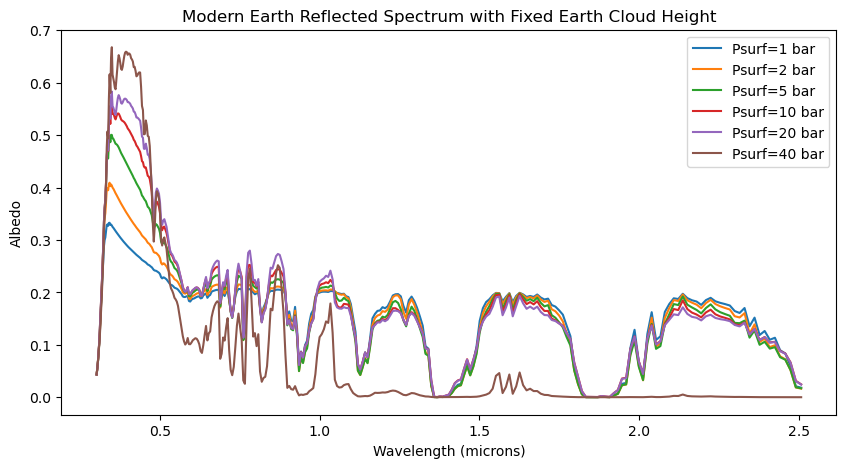

In [10]:
# Compare albedo spectra across surface pressure depths
fig, ax = plt.subplots(1, figsize=(10, 5))

for p_surf in surface_pressure_grid:
    res = results[p_surf]
    ax.plot(1e4 / res['wno'], res['albedo'], lw=1.5, label=f"Psurf={p_surf:g} bar")

ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Albedo')
ax.set_title('Modern Earth Reflected Spectrum with Fixed Earth Cloud Height')
ax.legend()
plt.show()

In [7]:
import h5py

def save_reflected_sweep_to_hdf5(results_dict, filename="Modern_earth_surface_pressure_sweep.h5", earth_type="Modern"):
    """Save reflected spectra sweep results to HDF5 in a phase/group style."""
    with h5py.File(filename, "w") as f:
        f.attrs["earth_type"] = earth_type
        f.attrs["phase_radians"] = 0.0
        f.attrs["num_surface_pressures"] = len(results_dict)
        f.attrs["cloud_ptop_bar"] = 0.6
        f.attrs["cloud_pbot_bar"] = 0.7

        phase_grp = f.create_group("phase_0.0000")

        for p_surf, res in sorted(results_dict.items()):
            case_grp = phase_grp.create_group(f"surface_pressure_{p_surf:g}_bar")
            case_grp.attrs["p_surface_bar"] = float(res["p_surface_bar"])
            case_grp.attrs["cloud_ptop_bar"] = float(res["cloud_ptop_bar"])
            case_grp.attrs["cloud_pbot_bar"] = float(res["cloud_pbot_bar"])

            case_grp.create_dataset("wno", data=np.asarray(res["wno"]), compression="gzip", chunks=True)
            case_grp.create_dataset("fpfs", data=np.asarray(res["fpfs"]), compression="gzip", chunks=True)
            case_grp.create_dataset("alb", data=np.asarray(res["albedo"]), compression="gzip", chunks=True)

    print(f"Saved reflected spectra sweep to {filename}")

# Save results from the pressure sweep
save_reflected_sweep_to_hdf5(results)

Saved reflected spectra sweep to Modern_earth_surface_pressure_sweep.h5
